In [ ]:
from loaders import load_tisch, load_sept, load_bible, load_references
import numpy as np
import pandas as pd

In [ ]:
bible = load_bible()
bible.index = np.arange(len(bible))
references = load_references()

In [ ]:
bible_books = bible["book"].unique()
book_map = pd.Series(np.arange(1, len(bible_books) + 1), index=bible_books)
bible["booknum"] = book_map[bible["book"]].values

In [ ]:
bible["reference_text"] = False

for ostart, oend, nstart, nend in references[
    ["ostart", "oend", "nstart", "nend"]
].values:
    bible.loc[ostart : oend - 1, "reference_text"] = True
    bible.loc[nstart : nend - 1, "reference_text"] = True

In [ ]:
ot = bible.query("booknum < 40")
nt = bible.query("booknum >= 40")
ot_books = ot["book"].unique()
nt_books = nt["book"].unique()

In [ ]:
references["obook"] = bible.iloc[references["ostart"]]["book"].values
references["nbook"] = bible.iloc[references["nstart"]]["book"].values

In [ ]:
use_counts = (
    references.groupby("nbook")
    .apply(
        lambda subreferences: subreferences.groupby("obook")["nlen"].sum(),
        include_groups=False,
    )
    .unstack()
    .reindex(nt_books, columns=ot_books)
    .fillna(0)
    .astype(int)
)
use_counts["total"] = nt.groupby("book")["reference_text"].sum()
use_counts["len"] = nt["book"].value_counts()

In [ ]:
import seaborn as sns
sns.set_theme(style='white')

In [ ]:
use_props = use_counts.drop(columns='len') / use_counts['len'].values[:, None]
use_props['total'][::-1].plot.barh(ylabel='');
#use_props.drop(columns='total', inplace=True)

In [ ]:
use_props.drop(columns='total').T.sum(axis=1)[::-1].plot.barh(ylabel='');

In [ ]:
from sklearn.decomposition import PCA

use_props.drop(columns='total', inplace=True)
pca = PCA(n_components=2)

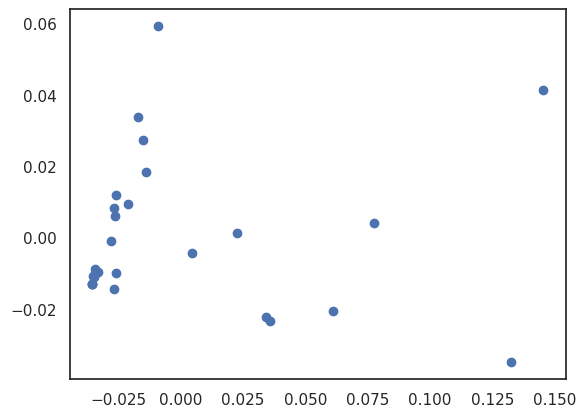

In [33]:
new_comps = pca.fit_transform(use_props)
# annotate the ith point with use_props.index[i]
plt.scatter(new_comps[:, 0], new_comps[:, 1])